In [1]:
# libraries 
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# load iris dataset 
iris = load_iris()

print("Iris dataset loaded successfully ")

Iris dataset loaded successfully 


In [3]:
# Display the available information in the Iris dataset

print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
# Create a DataFrame from the Iris features

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Create the target variable

y = pd.Series(
    iris.target,
    name="target"
)

# Display the first five rows

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# check the dataset shape 
print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (150, 4)
Target dataset shape: (150,)


In [6]:
# check the target classes 
print("Target names:", iris.target_names)

Target names: ['setosa' 'versicolor' 'virginica']


In [7]:
# Combine features and target into one DataFrame

df = X.copy()

df["target"] = y

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [8]:
print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (150, 4)
Target dataset shape: (150,)


In [9]:
# display feature names 
# Display feature names

print("Feature Names:")
for feature in iris.feature_names:
    print("-", feature)

Feature Names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [10]:
# Display target classes

print("Target Classes:")

for i, name in enumerate(iris.target_names):
    print(i, "→", name)

Target Classes:
0 → setosa
1 → versicolor
2 → virginica


In [11]:
# Check for missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [12]:
# Display statistical summary

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [13]:
# Check how many samples belong to each class

print(df["target"].value_counts().sort_index())

target
0    50
1    50
2    50
Name: count, dtype: int64


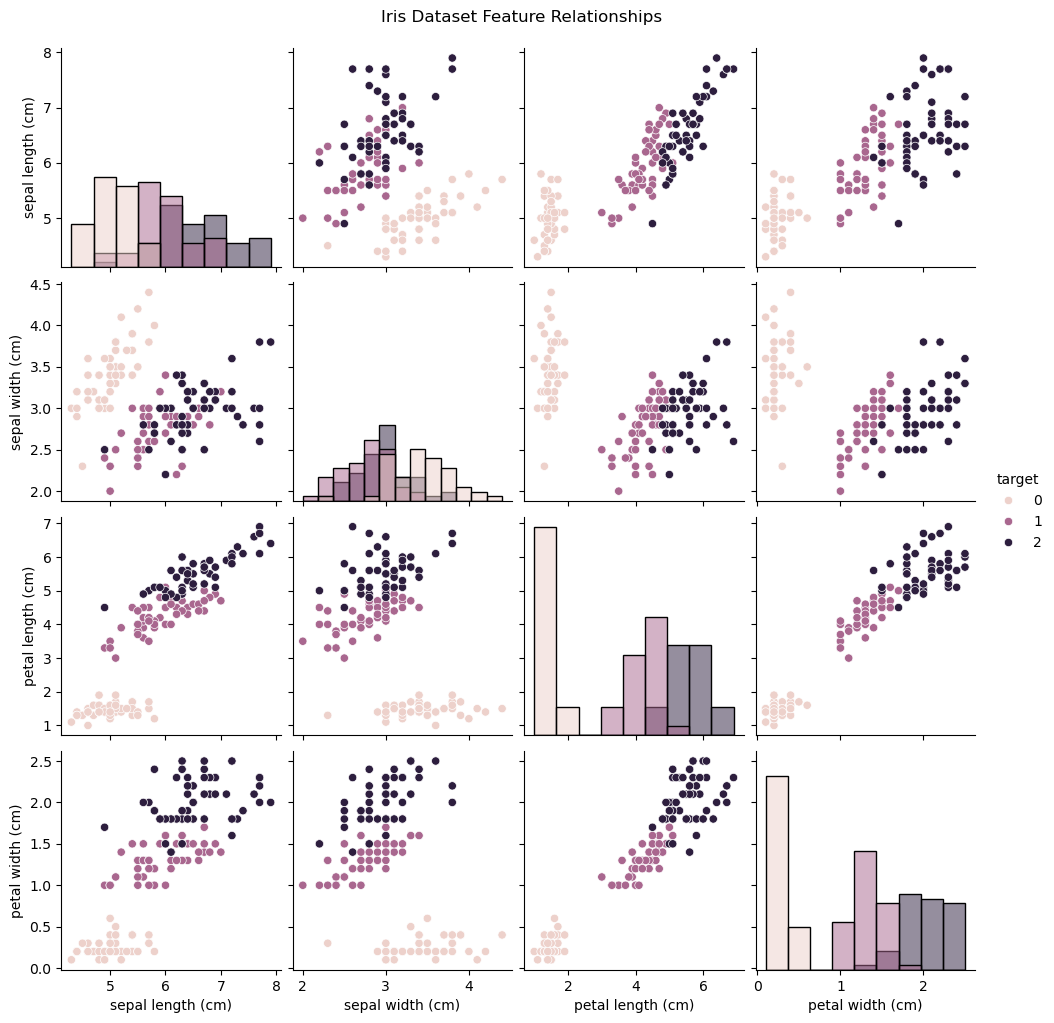

In [14]:
# Visualize feature relationships

sns.pairplot(
    df,
    hue="target",
    diag_kind="hist"
)

plt.suptitle("Iris Dataset Feature Relationships", y=1.02)

plt.show()

In [15]:
# separate feature and target 
X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

In [16]:
# Separate input features (X) and target (y)

X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [18]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object

scaler = StandardScaler()

In [19]:
# Scale the input features

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (150, 4)


In [20]:
# Display the first five scaled records

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [21]:
# Convert scaled data into a DataFrame

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=iris.feature_names
)

X_scaled_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [23]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


In [24]:
# Create the scaler

scaler = StandardScaler()

# Fit the scaler on training data and transform training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler

X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (120, 4)
Scaled testing data: (30, 4)


In [25]:
# Train the KNN Classification 

In [27]:
# Import K-Nearest Neighbors classifier

from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier

knn_model = KNeighborsClassifier(n_neighbors=5)

In [28]:
# Train the KNN model

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [29]:
# Make predictions on test data

y_pred = knn_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


In [30]:
# Compare actual and predicted values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


In [31]:
# converting class numbers into flower names 
# Convert numeric predictions to flower names

actual_names = iris.target_names[y_test.values]
predicted_names = iris.target_names[y_pred]

comparison_names = pd.DataFrame({
    "Actual": actual_names,
    "Predicted": predicted_names
})

comparison_names

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


In [33]:
# calculate accuracy 
from sklearn.metrics import accuracy_score

# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9333333333333333
Accuracy (%): 93.33333333333333


In [34]:
# generate the classification report 
from sklearn.metrics import classification_report


# Generate classification report

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [35]:
# Confusion matrix 
from sklearn.metrics import  confusion_matrix

# Calculate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


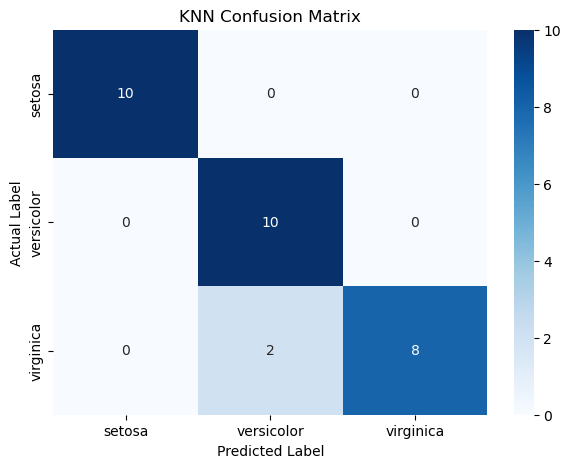

In [36]:
# Plot confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("KNN Confusion Matrix")

plt.show()

In [37]:
# Store model evaluation results

print("=" * 40)
print("KNN MODEL EVALUATION")
print("=" * 40)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

KNN MODEL EVALUATION
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [38]:
import joblib

In [39]:
KNeighborsClassifier(n_neighbors=5)

KNeighborsClassifier()

In [40]:
# Create the final KNN model with K = 5

final_model = KNeighborsClassifier(n_neighbors=5)

final_model.fit(X_train_scaled, y_train)

print("Final KNN model trained successfully.")

Final KNN model trained successfully.


In [41]:
# Save the trained KNN model

joblib.dump(final_model, "knn_model.pkl")

print("KNN model saved successfully!")

KNN model saved successfully!


In [42]:
# Save the StandardScaler

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [44]:
# # Load the saved model and scaler

# loaded_model = joblib.load("model/knn_model.pkl")
# loaded_scaler = joblib.load("model/scaler.pkl")

# print("Saved model and scaler loaded successfully!")

In [45]:
# Test model with new data 
# Sepal Length = 5.1 cm
# Sepal Width  = 3.5 cm
# Petal Length = 1.4 cm
# Petal Width  = 0.2 cm

In [46]:
# New flower data

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

print("New flower data:")
print(new_flower)

New flower data:
[[5.1 3.5 1.4 0.2]]


In [47]:
# Scale the new flower data

new_flower_scaled = scaler.transform(new_flower)

print("Scaled new flower:")
print(new_flower_scaled)

Scaled new flower:
[[-0.88566202  1.01122923 -1.34572231 -1.32327558]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [48]:
# Predict the flower class

new_prediction = final_model.predict(new_flower_scaled)

print("Predicted class:", new_prediction)

Predicted class: [0]


In [49]:
# Convert prediction number to flower name

predicted_flower = iris.target_names[new_prediction[0]]

print("Predicted flower:", predicted_flower)

Predicted flower: setosa


In [50]:
print("=" * 40)
print("NEW FLOWER PREDICTION")
print("=" * 40)

print(f"Sepal Length : {new_flower[0][0]} cm")
print(f"Sepal Width  : {new_flower[0][1]} cm")
print(f"Petal Length : {new_flower[0][2]} cm")
print(f"Petal Width  : {new_flower[0][3]} cm")

print("-" * 40)

print(f"Predicted Flower: {predicted_flower.upper()}")

NEW FLOWER PREDICTION
Sepal Length : 5.1 cm
Sepal Width  : 3.5 cm
Petal Length : 1.4 cm
Petal Width  : 0.2 cm
----------------------------------------
Predicted Flower: SETOSA
